In [1]:
import os
import nltk
import spacy
import string
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from nltk.corpus import stopwords
from mlflow.models.signature import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [2]:
mlflow.set_tracking_uri("http://localhost:5012")

mlflow.autolog(log_models=False)

if not mlflow.get_experiment_by_name(name="TF_IDF Model"):
    print("Creating model...")
    mlflow.create_experiment(name="TF_IDF Model", artifact_location="mlflow-artifacts:/tfidf_model")


if not mlflow.get_experiment_by_name(name="Count Model"):
    print("Creating model...")
    mlflow.create_experiment(name="Count Model", artifact_location="mlflow-artifacts:/count_model")


tfidf_experiment = mlflow.get_experiment_by_name(name="TF_IDF Model")
count_experiment = mlflow.get_experiment_by_name(name="Count Model")

2026/05/16 00:10:54 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [3]:
IMDB_DATA_PATH = "data/raw/imdb.csv"

# Pre Processing

In [4]:
def clean_text(text: str) -> str:
    """
    Do some text cleaning and tokenizing
    """

    text = str(text).lower()
    text = text.replace("<br />", " ") # Remove html tags
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    doc = nlp(text)
    cleaned_tokens = [
        token.lemma_ for token in doc
        if token.text not in stop_words and token.is_alpha
    ]

    return " ".join(cleaned_tokens)

In [5]:
# Download stopwords
if not os.path.exists(IMDB_DATA_PATH):
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

    nlp = spacy.load("en_core_web_sm")

    df = pd.read_csv("https://iai.fsn1.your-objectstorage.com/imdb_dataset.csv")

    tqdm.pandas(desc='Cleaning Text...') 
    df['review_clean'] = df['review'].progress_apply(clean_text)

    df.to_csv(IMDB_DATA_PATH, columns=['sentiment', 'review_clean'], index=False)

In [6]:
mlflow.get_artifact_uri()
mlflow.end_run()

2026/05/16 00:10:54 WARNING mlflow.tracking.fluent: No active run found. A new active run will be created. If this is not intended, please create a run using `mlflow.start_run()` first.


🏃 View run lyrical-elk-396 at: http://localhost:5012/#/experiments/0/runs/d720d089372a436194aecc73c70cea94
🧪 View experiment at: http://localhost:5012/#/experiments/0


# Model Training

In [7]:
df_tfidf = pd.read_csv(IMDB_DATA_PATH)

In [8]:
# Map string to int
df_tfidf['sentiment'] = df_tfidf['sentiment'].map({'positive': 1, 'negative': 0})

In [9]:
dataset = load_dataset("imdb", cache_dir="data/cache")

In [10]:
vecorizer = CountVectorizer()
tfidf = TfidfVectorizer()

In [11]:
data_count = vecorizer.fit_transform(dataset['train']['text'])
data_tfidf = tfidf.fit_transform(df_tfidf['review_clean'])

In [12]:
x_train_count, x_test_count, y_train_count, y_test_count = train_test_split(data_count, dataset['train']['label'], test_size=0.2, random_state=42)
x_train_tfidf, x_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(data_tfidf, df_tfidf['sentiment'].values, test_size=0.2, random_state=42)

In [13]:
with mlflow.start_run(experiment_id=count_experiment.experiment_id):
    model_count = LogisticRegression(random_state=42, max_iter=1000)
    model_count.fit(x_train_count, np.array(y_train_count))

    # Generate Signature to save on mem usage
    sig = infer_signature(x_train_count[:100], model_count.predict(x_train_count[:100]))

    # Log the sklearn model and register as version 1
    mlflow.sklearn.log_model(
        sk_model=model_count,
        name="model_count",
        input_example=x_train_count[:100],
        registered_model_name="sk-learn-log-reg-count",
        signature=sig
    )

    count_run = mlflow.active_run().info

2026/05/16 00:11:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sk-learn-log-reg-count' already exists. Creating a new version of this model...
2026/05/16 00:11:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-log-reg-count, version 7
Created version '7' of model 'sk-learn-log-reg-count'.


🏃 View run classy-roo-765 at: http://localhost:5012/#/experiments/2/runs/e5df9de1bba9499bbe510fc994cb0ebb
🧪 View experiment at: http://localhost:5012/#/experiments/2


In [14]:
with mlflow.start_run(experiment_id=tfidf_experiment.experiment_id):
    model_tfidf = LogisticRegression(random_state=42, max_iter=1000)
    model_tfidf.fit(x_train_tfidf, y_train_tfidf)

    # Generate Signature to save on mem usage
    sig = infer_signature(x_train_tfidf[:100], model_tfidf.predict(x_train_tfidf[:100]))

    # Log the sklearn model and register as version 1
    mlflow.sklearn.log_model(
        sk_model=model_tfidf,
        name="model_tfidf",
        input_example=x_train_tfidf[:10],
        registered_model_name="sk-learn-log-reg-tfidf",
        signature=sig
    )

    tfidf_run = mlflow.active_run().info

2026/05/16 00:12:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sk-learn-log-reg-tfidf' already exists. Creating a new version of this model...
2026/05/16 00:12:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-log-reg-tfidf, version 5
Created version '5' of model 'sk-learn-log-reg-tfidf'.


🏃 View run amazing-quail-45 at: http://localhost:5012/#/experiments/1/runs/b3370268d10745d5a9074f7dc48d007b
🧪 View experiment at: http://localhost:5012/#/experiments/1


Accuracy_score     0.8804
Recall_score       0.8930
Precision_score    0.8930


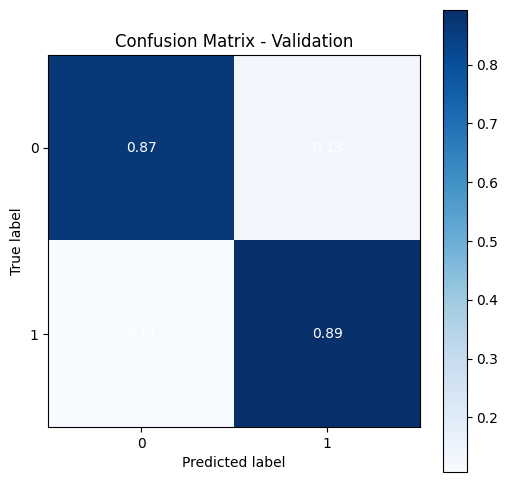

🏃 View run amazing-quail-45 at: http://localhost:5012/#/experiments/1/runs/b3370268d10745d5a9074f7dc48d007b
🧪 View experiment at: http://localhost:5012/#/experiments/1


In [15]:
prediction_count = model_count.predict(x_test_count)

scores_count = np.array([[
    accuracy_score(y_test_count, prediction_count),
    recall_score(y_test_count, prediction_count),
    precision_score(y_test_count, prediction_count),
]])

print(f"{'Accuracy_score':<18} {scores_count[0][0]:.4f}")
print(f"{'Recall_score':<18} {scores_count[0][1]:.4f}")
print(f"{'Precision_score':<18} {scores_count[0][1]:.4f}")

mlflow.log_metrics(run_id=count_run.run_id, metrics={
    "testing_accuracy_score": scores_count[0][0],
    "testing_recall_score": scores_count[0][1],
    "testing_precision_score": scores_count[0][2],
})

# Generate and save Confusion Matrix
cm = confusion_matrix(y_test_count, prediction_count, normalize="true")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=model_count.classes_).plot(ax=ax, cmap="Blues", text_kw={"color": "white"})
ax.set_title("Confusion Matrix - Validation")

plt.show()

with mlflow.start_run(run_id=tfidf_run.run_id):
    mlflow.log_figure(fig, "val_confusion_matrix.png")

plt.close()


Accuracy_score     0.8918
Recall_score       0.9065
Precision_score    0.8820


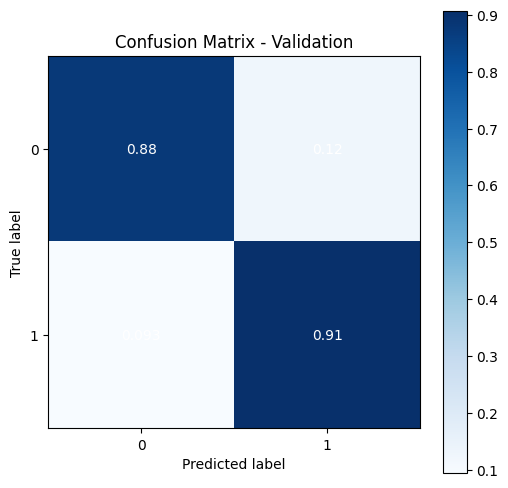

🏃 View run amazing-quail-45 at: http://localhost:5012/#/experiments/1/runs/b3370268d10745d5a9074f7dc48d007b
🧪 View experiment at: http://localhost:5012/#/experiments/1


In [16]:
prediction_tfidf = model_tfidf.predict(x_test_tfidf)

scores_tfidf = np.array([[
    accuracy_score(y_test_tfidf, prediction_tfidf),
    recall_score(y_test_tfidf, prediction_tfidf),
    precision_score(y_test_tfidf, prediction_tfidf),
]])

print(f"{'Accuracy_score':<18} {scores_tfidf[0][0]:.4f}")
print(f"{'Recall_score':<18} {scores_tfidf[0][1]:.4f}")
print(f"{'Precision_score':<18} {scores_tfidf[0][2]:.4f}")

mlflow.log_metrics(run_id=tfidf_run.run_id, metrics={
    "testing_accuracy_score": scores_tfidf[0][0],
    "testing_recall_score": scores_tfidf[0][1],
    "testing_precision_score": scores_tfidf[0][2],
})

# Generate and save Confusion Matrix
cm = confusion_matrix(y_test_tfidf, prediction_tfidf, normalize="true")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=model_tfidf.classes_).plot(ax=ax, cmap="Blues", text_kw={"color": "white"})
ax.set_title("Confusion Matrix - Validation")

plt.show()

with mlflow.start_run(run_id=tfidf_run.run_id):
    mlflow.log_figure(fig, "val_confusion_matrix.png")

plt.close()

In [17]:
scores_delta = scores_tfidf - scores_count

print("Delta (TF_IDF vs Count) \n")

print(f"{'Accuracy_score':<18} {scores_delta[0][0]:.4f}")
print(f"{'Recall_score':<18} {scores_delta[0][1]:.4f}")
print(f"{'Precision_score':<18} {scores_delta[0][2]:.4f}")

Delta (TF_IDF vs Count) 

Accuracy_score     0.0114
Recall_score       0.0136
Precision_score    0.0122
